## **Overview**

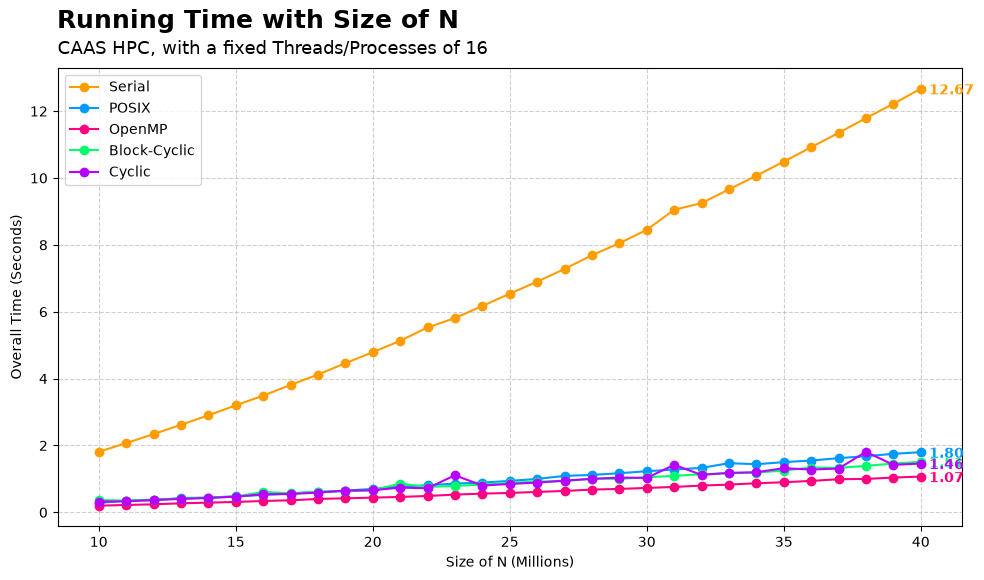

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# ADDED 'Serial Code' back to categories
categories = {
    'Serial Code': 'Serial',
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Added a 5th color (Soft Orange: #F39C12) for the Serial line
colors = ["#FF9D00", "#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and col[1] == 'Overall']
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round overall time to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Increased font sizes)
plt.suptitle("Running Time with Size of N", fontweight='bold', fontsize=18, y=0.96, ha='left', x=.062)
plt.title("CAAS HPC, with a fixed Threads/Processes of 16", fontsize=13, pad=10, loc='left')

# Axis labels and legend (Renamed X-axis)
plt.xlabel("Size of N (Millions)")
plt.ylabel("Overall Time (Seconds)")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_overview.png", dpi=300)
plt.show()

## **Graph 1**
**Comparing the running time with the size of N for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

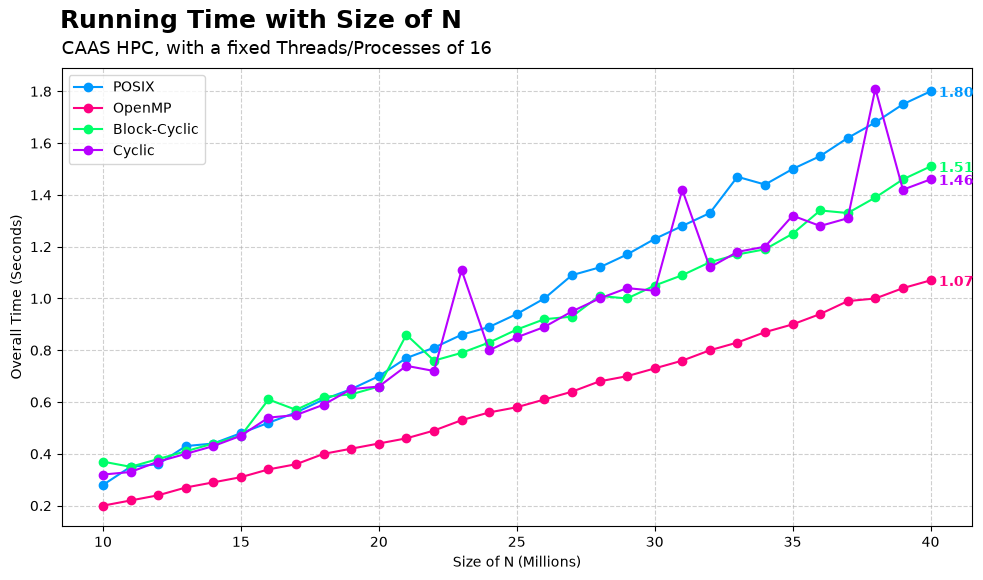

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# Removed 'Serial Code' from categories
categories = {
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Updated colors: Light Blue, Pink, Light Green, Light Purple (vibrant, not too pale)
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and col[1] == 'Overall']
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round overall time to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Increased font sizes)
plt.suptitle("Running Time with Size of N", fontweight='bold', fontsize=18, y=0.96, ha='left', x=.065)
plt.title("CAAS HPC, with a fixed Threads/Processes of 16", fontsize=13, pad=10, loc='left')

# Axis labels and legend (Renamed X-axis)
plt.xlabel("Size of N (Millions)")
plt.ylabel("Overall Time (Seconds)")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_runTime.png", dpi=300)
plt.show()

## **Graph 2**
**Comparing the empirical speedup with the size of N for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

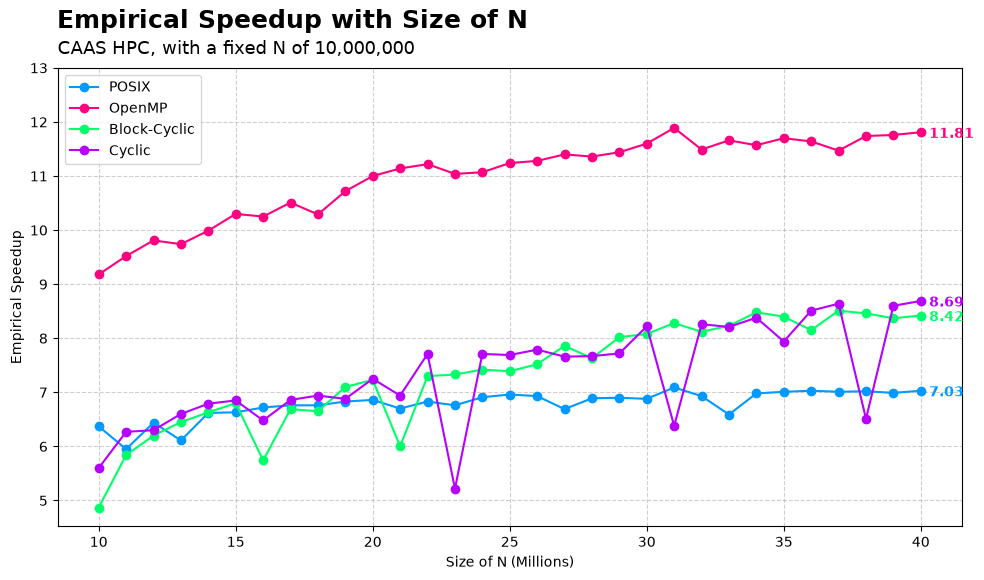

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# Categories for Empirical Speedup
categories = {
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    # Find the matching column for the current category and its 'E Speedup' sub-column
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and 'E Speedup' in str(col[1])]
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round empirical speedup to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Size of N", fontweight='bold', fontsize=18, x=.062, y=.96, ha='left')
plt.title("CAAS HPC, with a fixed N of 10,000,000", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Size of N (Millions)")
plt.ylabel("Empirical Speedup")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Set Y-axis limit so the max is 12 (starts at 0 by default, adjusting top only)
plt.ylim(top=13)

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_eSpeedup_N.png", dpi=300)
plt.show()

## **Graph 3**
**Comparing the empirical speedup with the number of threads/processes for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

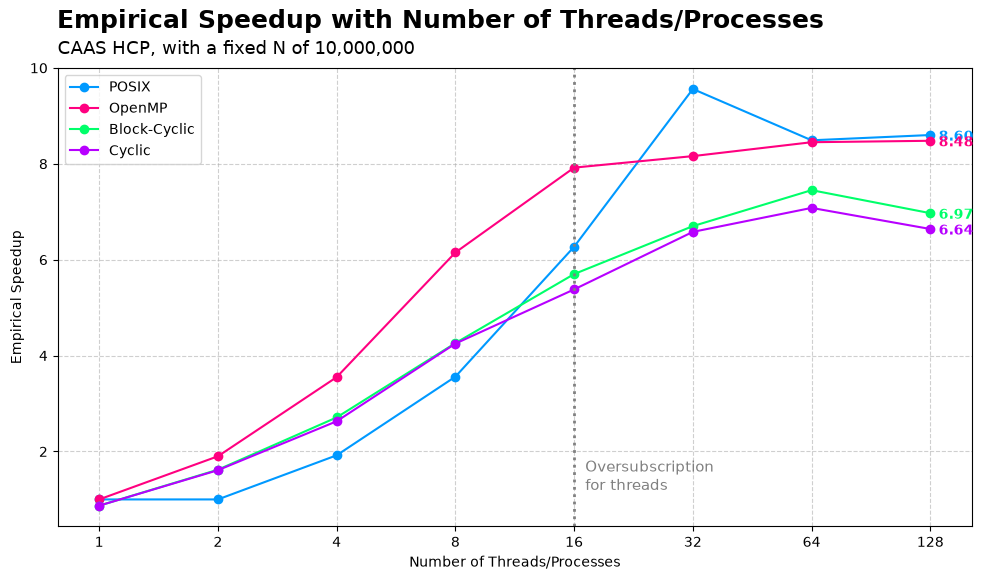

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"

# Updated header to [36, 37] based on the row numbers
df = pd.read_excel(file_name, sheet_name="CAAS", header=[36, 37])

# Clean up the first column (Number of Threads/Processes): convert to numeric
x_col = df.columns[0]
df[x_col] = pd.to_numeric(df[x_col], errors='coerce')

# Drop NaN values and filter > 0 (Log scales cannot plot 0)
df = df.dropna(subset=[x_col])
df = df[df[x_col] > 0]
df = df.sort_values(by=x_col).reset_index(drop=True)

x_values = df[x_col]

# Categories for Empirical Speedup
categories = {
    'POSIX': 'POSIX',
    'OpenMP': 'OpenMP',
    'Open MPI Block-Cyclic': 'Block-Cyclic',
    'Open MPI Cyclic': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    # Find the matching column for the current category and its 'E Speedup' sub-column
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and 'E Speedup' in str(col[1])]
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round empirical speedup to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Number of Threads/Processes", fontweight='bold', fontsize=18, x=0.062, y=0.96, ha='left')
plt.title("CAAS HCP, with a fixed N of 10,000,000", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Threads/Processes")
plt.ylabel("Empirical Speedup")
plt.legend()

# NEW: Add a dotted vertical line at x=16 and its wrapped label at the top right
plt.axvline(x=16, color='gray', linestyle=':', linewidth=2)
plt.annotate('Oversubscription\nfor threads', 
             xy=(16, 2),            # Position at the top of the Y-axis (since max is 10)
             xytext=(8, -5),         # Offset 8 points to the right and slightly down
             textcoords='offset points',
             va='top',               # Align text from the top so it drops down
             ha='left',              # Align left to the offset
             color='gray',
             fontsize=11)

# Set X-axis to a Base-2 Logarithmic scale to evenly space 1, 2, 4, 8, 16...
plt.xscale('log', base=2)

# Set X-axis ticks explicitly and force them to render as plain numbers
ticks = [1, 2, 4, 8, 16, 32, 64, 128]
plt.xticks(ticks, labels=[str(t) for t in ticks])

# Set Y-axis limit so the max is 10
plt.ylim(top=10)

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_eSpeedup_TP.png", dpi=300)
plt.show()